# Week 6 Homework

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(2026)

**1. (50 pts). You have three different datasets to visualize. For each, choose the most appropriate colormap and justify your choice:**   
**1. Dataset A: Temperature anomalies ranging from -5°C to +8°C (where 0 means "no change")**   
**2. Dataset B: Sherd density (values from 0 to 5000 sherds per m²)**   
**3. Dataset C: Categorical land use data with 5 categories (forest, water, urban, agriculture, desert)**   

**Create a figure with three subplots, each using an appropriate colormap. Add colorbars (these should be of the same length/width as the main axes). Add appropriate ancillary information (title, labels, etc)**

*Hint. Consider creating a colormap when the middle value is not symmetrical*

***DATA***

In [35]:
# Dataset A: Temperature anomalies
temp_anomaly = np.random.uniform(-5, 8, (20, 20))
#^a diverging colormap and recentering on zero to indicate value and direction of deviation (RdBu_r)

# Dataset B: Sherd density 
sherds = np.random.exponential(500, (20, 20))
sherds = np.clip(sherds, 0, 5000)
#^Using plasma, which varies evenly toward high brighteness and heat. 
#This highlights outliers and displays the uneven distribution

# Dataset C: Categorical land use
land_use = np.random.randint(0, 5, (20, 20))
#using cividis. Bicromatic and perceptually uniform. This allows user to see the distinct integer levels

In [ ]:
##explanation above

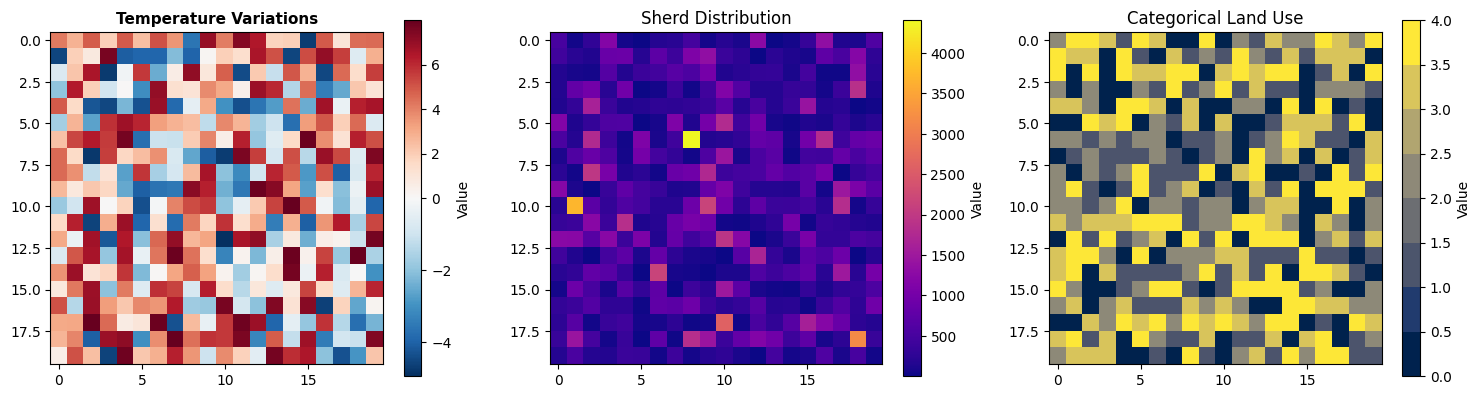

In [49]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize, TwoSlopeNorm, LogNorm
import matplotlib.colors as mcolors
from matplotlib import cm
import warnings
#TEMPERATURE DEVIATIONS
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#^a diverging colormap and recentering on zero to indicate value and direction of deviation (RdBu_r)
norm = TwoSlopeNorm(vcenter=0, vmin=temp_anomaly.min(), vmax=temp_anomaly.max())
im1 = axes[0].imshow(temp_anomaly, cmap='RdBu_r', norm=norm)
axes[0].set_title('Temperature Variations', size=11, weight='bold')
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label('Value')

#SHERDS
#^Using plasma, which varies evenly toward high brighteness and heat. 
#This highlights outliers and displays the uneven distribution
im2 = axes[1].imshow(sherds, cmap='plasma')
axes[1].set_title('Sherd Distribution')
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label('Value')

#CATEGORIACAL LAND USE
#using cividis. Bicromatic and perceptually uniform. This allows user to see the distinct integer levels
#n=8 (each integer has it's own color value
cividis_n = plt.get_cmap('cividis', n)
im3 = axes[2].imshow(land_use, cmap=cividis_n)
axes[2].set_title('Categorical Land Use')
cbar3 = fig.colorbar(im3, ax=axes[2])
cbar3.set_label('Value')

plt.tight_layout()
plt.show()

**2. (50 pts) You're visualizing ocean bathymetry (depth) data. Create a custom colormap that transitions through specific colors at specific depth thresholds:**

| Depth | Color | Hex Code |
|-------|-------|----------|
| 0 m (surface) | light cyan | `'#E0FFFF'` |
| -65 m (shallow) | turquoise | `'#40E0D0'` |
| -150 m (mid-depth) | navy blue | `'#000080'` |
| -233 m (deep ocean) | near-black | `'#0A0A20'` |

**Plot the depth data and add a colorbar with surface (0) at the top and deep (-233) at the bottom. Colorbar should be of the same height or width as the main axes.**

*Hints:*
- `Normalize()` maps your data range to 0–1: calling `norm(value)` returns the position
- Remember that colormap position 0.0 corresponds to `vmin` and 1.0 corresponds to `vmax`
- You may need to reverse the order of your position-color pairs. To reverse a list a, a[::-1]

***DATA:***

In [80]:
from matplotlib.colors import 
from matplotlib.colors import Normalize

# Simulated ocean depth data (0 = surface, -233 = deepest)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
depth = -233 * np.sqrt(X**2 + Y**2) / np.sqrt(18)  # Ranges from 0 to -233
depth = np.clip(depth, -233, 0)

# Depth breakpoints and corresponding colors
depths = np.array([0, -65, -150, -233])
colors = ['#E0FFFF', '#40E0D0', '#000080', '#0A0A20']

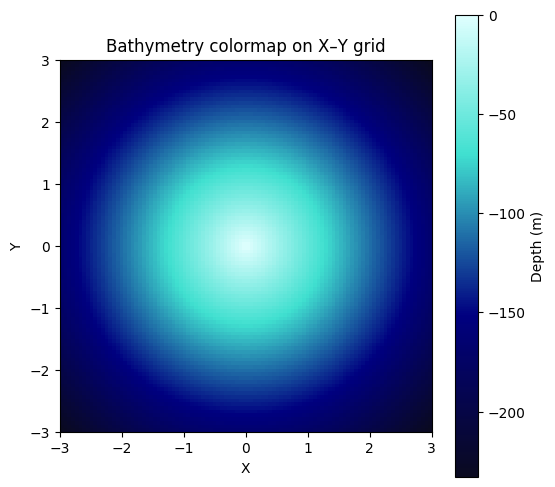

In [85]:

# custom sea_map

sea_map = LinearSegmentedColormap.from_list(
    "sea",
    [
        (0.00, '#0A0A20'),  # deepest trench
        (0.35, '#000080'),  # deep water
        (0.70, '#40E0D0'),  # mid shelf
        (1.00, '#E0FFFF')   # surface/shallow
    ]
)

# normalize to your depth range
norm = Normalize(vmin=-233, vmax=0)

fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    depth,
    cmap=sea_map,
    norm=norm,
    extent=[x.min(), x.max(), y.min(), y.max()],  # maps array -> real coords
    origin="lower"
)

ax.set_title("Bathymetry colormap on X–Y grid")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.colorbar(im, ax=ax, label="Depth (m)")
plt.show()